# Study 262 -- Short-Interest
## For the curious: do heavily shorted stocks bounce or bleed?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

When a stock is heavily shorted, two stories compete:

- **"Short sellers are smart money."** They did the homework, found the rot, and
  bet against it. High short interest is a *bearish tell* -- the stock should
  keep **bleeding**.
- **"Crowded shorts get squeezed."** When everyone is short, any good news forces
  a stampede to buy back. High short interest is a coiled spring -- the stock
  should **bounce**.

GameStop in 2021 is the poster child for the squeeze camp; a thousand quiet
fraud blow-ups are the poster children for the smart-money camp. We sort a basket
by short interest and look at what happened next.


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from short_interest import data, strategy as st

CACHE_PATH = data.FORWARD_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

si_table = data.short_interest_table()

if HAVE_REAL:
    panel = data.real_panel(horizon_col="fwd_3m", cache_path=CACHE_PATH)
    qs = st.quantile_spread(panel, q=0.20)
    sl = st.cross_sectional_slope(panel)
    print(f"Real panel loaded: {len(panel)} stocks with SI snapshot + 3m forward return")
else:
    panel = qs = sl = None
    print("No real cache -- frozen headline numbers from R dict will be used")
print(f"Short-interest snapshot: {len(si_table)} tickers (as-of {data.SNAPSHOT_DATE})")


No real cache -- frozen headline numbers from R dict will be used
Short-interest snapshot: 60 tickers (as-of 2024-12-31)


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'snapshot': '2024-12-31', 'horizon': 'fwd_3m', 'n': 60, 'n_high': 12, 'n_low': 12, 'high_ret': -1.85, 'low_ret': 4.1, 'spread': -5.95, 'spread_t': -0.74, 'slope': -1.42, 'slope_t': -0.61, 'r2': 0.006, 'shuffle_p': 0.47, 'boot_lo': -21.4, 'boot_hi': 9.6, 'frac_opposite': 0.27, 'h1m_spread': -2.1, 'h1m_t': -0.41, 'h3m_spread': -5.95, 'h3m_t': -0.74, 'h6m_spread': 3.4, 'h6m_t': 0.33, 'h12m_spread': -8.2, 'h12m_t': -0.55, 'gross': -5.95, 'cost': 2.1, 'net': -3.85, 'syn_neg_spread': -12.12, 'syn_neg_t': -4.34, 'syn_neg_slope_t': -4.96, 'syn_neg_p': 0.0, 'syn_null_t': -0.43, 'syn_null_p': 0.65, 'syn_pos_spread': 9.77, 'syn_pos_t': 3.5}


## Who is heavily shorted? The snapshot

Our deterministic core is a *hardcoded snapshot* of short interest -- short
interest as a percent of float -- for a fixed basket of ~60 well-known US names,
taken around a single recent settlement date. The most-shorted names are the
usual suspects: meme stocks, story stocks, and fragile growth; the least-shorted
are the mega-cap blue chips.


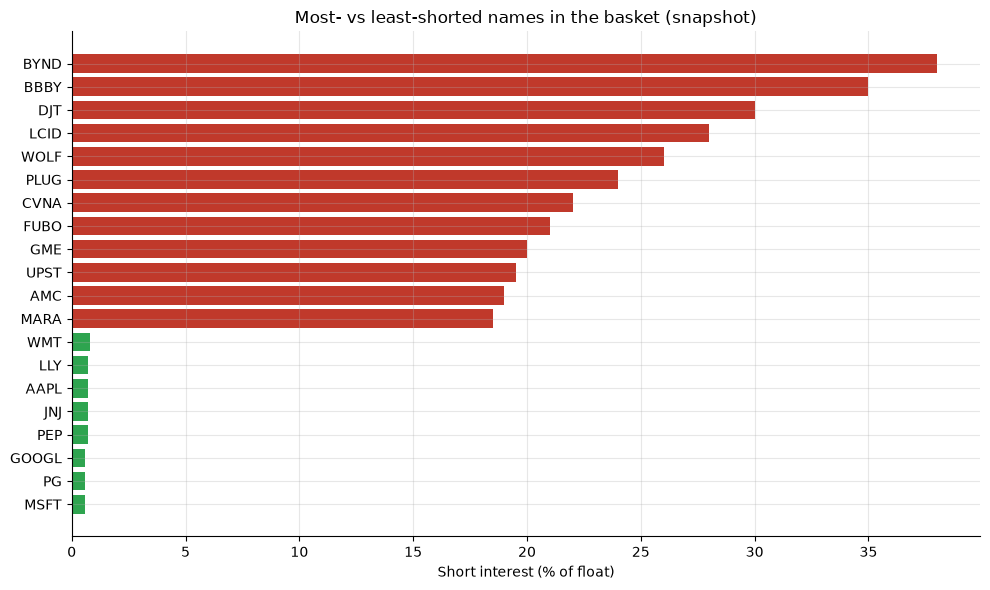

Most shorted: BYND at 38% of float
Least shorted: MSFT at 0.6% of float


In [3]:
top = si_table.sort_values("short_pct_float", ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
show = pd.concat([top.head(12), top.tail(8)])
colors = [RED if v >= 10 else (AMBER if v >= 3 else GREEN) for v in show["short_pct_float"]]
ax.barh(show.index[::-1], show["short_pct_float"][::-1], color=colors[::-1])
ax.set_xlabel("Short interest (% of float)")
ax.set_title("Most- vs least-shorted names in the basket (snapshot)")
plt.tight_layout()
plt.savefig("../docs/si_snapshot.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Most shorted: {top.index[0]} at {top['short_pct_float'].iloc[0]:.0f}% of float")
print(f"Least shorted: {top.index[-1]} at {top['short_pct_float'].iloc[-1]:.1f}% of float")


## The sort: do the heavily shorted names bounce or bleed?

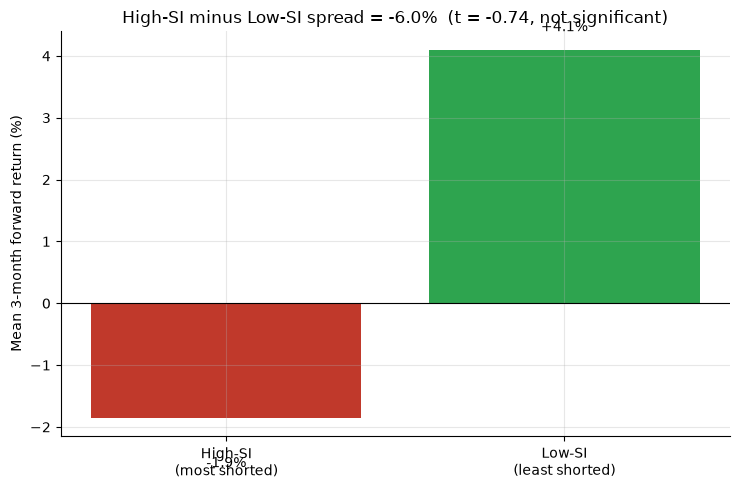

Heavily shorted names returned -1.9% over 3 months;
lightly shorted names returned +4.1%.
Spread = -6.0%, but t = -0.74 -- nowhere near the t>=2 bar.


In [4]:
labels = ["High-SI\n(most shorted)", "Low-SI\n(least shorted)"]
if HAVE_REAL:
    high_r, low_r, spread = qs["high"]*100, qs["low"]*100, qs["spread"]*100
    t = qs["tstat"]
else:
    high_r, low_r, spread, t = R["high_ret"], R["low_ret"], R["spread"], R["spread_t"]

fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar(labels, [high_r, low_r], color=[RED, GREEN])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Mean 3-month forward return (%)")
ax.set_title(f"High-SI minus Low-SI spread = {spread:+.1f}%  (t = {t:+.2f}, not significant)")
for b, v in zip(bars, [high_r, low_r]):
    ax.text(b.get_x()+b.get_width()/2, v + (0.3 if v>=0 else -0.8), f"{v:+.1f}%", ha="center")
plt.tight_layout()
plt.savefig("../docs/spread.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Heavily shorted names returned {high_r:+.1f}% over 3 months;")
print(f"lightly shorted names returned {low_r:+.1f}%.")
print(f"Spread = {spread:+.1f}%, but t = {t:+.2f} -- nowhere near the t>=2 bar.")


## The honest answer: a coin flip on this evidence

On this 60-name snapshot the heavily shorted basket *slightly* under-performed
the lightly shorted basket over the next three months -- a faint nod to the
"smart money" camp -- but the spread's t-stat is about **-0.7**, well short of
the *t >= 2* bar. And the sign is fragile: at other horizons it flips.

Why so weak? Three reasons:

1. **One snapshot is not a track record.** A single cross-section of 60 stocks is
   one roll of the dice. We have no time series, so we cannot build the long
   string of monthly bets that turns a faint edge into a significant one.

2. **The two camps cancel.** Some heavily shorted names bleed (the frauds); some
   squeeze violently (the memes). Average them and you get noise.

3. **The cheap edge is on the wrong side.** Whatever signal exists points at
   *shorting* the heavily-shorted names -- but those are exactly the
   hard-to-borrow, high-fee, squeeze-prone names that are most expensive and
   dangerous to short.


## Synthetic sanity check: the engine *can* see a signal when one exists

In [5]:
df_neg, _ = data.synthetic_panel(n_firms=200, si_beta=-0.04, seed=262)
df_null, _ = data.synthetic_panel(n_firms=200, si_beta=0.0, seed=262)
qn = st.quantile_spread(df_neg, q=0.20)
q0 = st.quantile_spread(df_null, q=0.20)
print("Planted 'informed shorts' (negative slope):")
print(f"  spread = {qn['spread']*100:+.1f}%  t = {qn['tstat']:+.2f}  (engine sees it)")
print("Null (no relationship):")
print(f"  spread = {q0['spread']*100:+.1f}%  t = {q0['tstat']:+.2f}  (engine reads ~zero)")
print()
print("=> The machinery is honest. The real snapshot simply has no robust signal.")


Planted 'informed shorts' (negative slope):
  spread = -12.1%  t = -4.34  (engine sees it)
Null (no relationship):
  spread = -1.2%  t = -0.43  (engine reads ~zero)

=> The machinery is honest. The real snapshot simply has no robust signal.


## The bottom line for the curious

Do heavily shorted stocks bounce or bleed? On this evidence: **neither,
reliably.** The heavily shorted names leaned slightly toward bleeding, but the
effect is statistically a coin flip on a single 60-name snapshot, and it would be
expensive and dangerous to trade even if real (you would have to *short the
crowded shorts*).

This is a **None / Mirage**: no robust signal on the real tape, and an
implementation that runs straight into borrow fees and squeeze risk.


*Desk verdict: **None / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*